In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Notebook illustrates
- loading psd data saved as numpy npz file 
- mask data of defined frequency band 
- average over frequency band
- save as pandas dataframe
- plot averaged psd over period

@ daniel binder
Golm, 09.06.2026
"""

import numpy as np
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set plot parameters
plt.rcParams.update({
    'font.size': 14,        
    'axes.titlesize': 28,   
    'axes.labelsize': 28,   
    'xtick.labelsize': 20,  
    'ytick.labelsize': 20,  
    'legend.fontsize': 20  
})

# Define station
station = '456'

# Define the file path
base_dir = Path("/media/db/DB_2TBext4/up_env_seismology")
data_dir = base_dir / '02_processed_data/ap23'
fn =  data_dir / f"{station}_20230701_0715.npz"

# Load psd data
with np.load(fn, allow_pickle=True) as data:
    # Extract the arrays with the defined the keys
    psd = data['psd']
    times = data['times']
    frequencies = data['frequencies']

print("Data loaded successfully!")
print(f"PSD Matrix Shape: {psd.shape}") # (hours, frequency_bins)
print(f"Time Matrix Shape: {times.shape}")

Data loaded successfully!
PSD Matrix Shape: (720, 60001)
Time Matrix Shape: (720,)


In [2]:
# Define the frequency band
fmin = 1
fmax = 10

# Find the array indices that match the frequency bounds
# This creates a boolean mask (True where frequencies are inside the band)
freq_mask = (frequencies >= fmin) & (frequencies <= fmax)

# Slice the PSD matrix to include only your target frequency columns
# Shape becomes: (total_hours, number_of_frequencies_in_band)
band_psd = psd[:, freq_mask]

# Calculate mean and median psds
# We use axis=1 to collapse the frequencies, giving you ONE value per hour
mean_psd = np.mean(band_psd, axis=1)
median_psd = np.median(band_psd, axis=1)

# Create DataFrame using your loaded times vector directly as the index
df_psd = pd.DataFrame(
    data={
        'mean_psd': mean_psd,
        'median_psd': median_psd
    },
    index=pd.to_datetime(times)
)

print(f"--- Frequency Band: {fmin} to {fmax} Hz ---")
print(df_psd.head())

# Create filename
csv_fn = (
    f"{station}_psd_{fmin}_{fmax}Hz"+
    '_'+
    str(df_psd.index.min().strftime("%Y%m%d"))+
    '_'+ 
    str(df_psd.index.max().strftime("%m%d"))+
    '.csv'
)
# Save data
df_psd.to_csv(data_dir / csv_fn)
print("Averaged PSD data saved.")


--- Frequency Band: 1 to 10 Hz ---
                         mean_psd    median_psd
2023-07-01 00:15:00  3.451765e-14  8.225346e-15
2023-07-01 00:45:00  9.319487e-14  2.806097e-14
2023-07-01 01:15:00  9.039227e-14  3.136217e-14
2023-07-01 01:45:00  7.480792e-14  2.111046e-14
2023-07-01 02:15:00  9.397701e-14  2.878875e-14
Averaged PSD data saved.


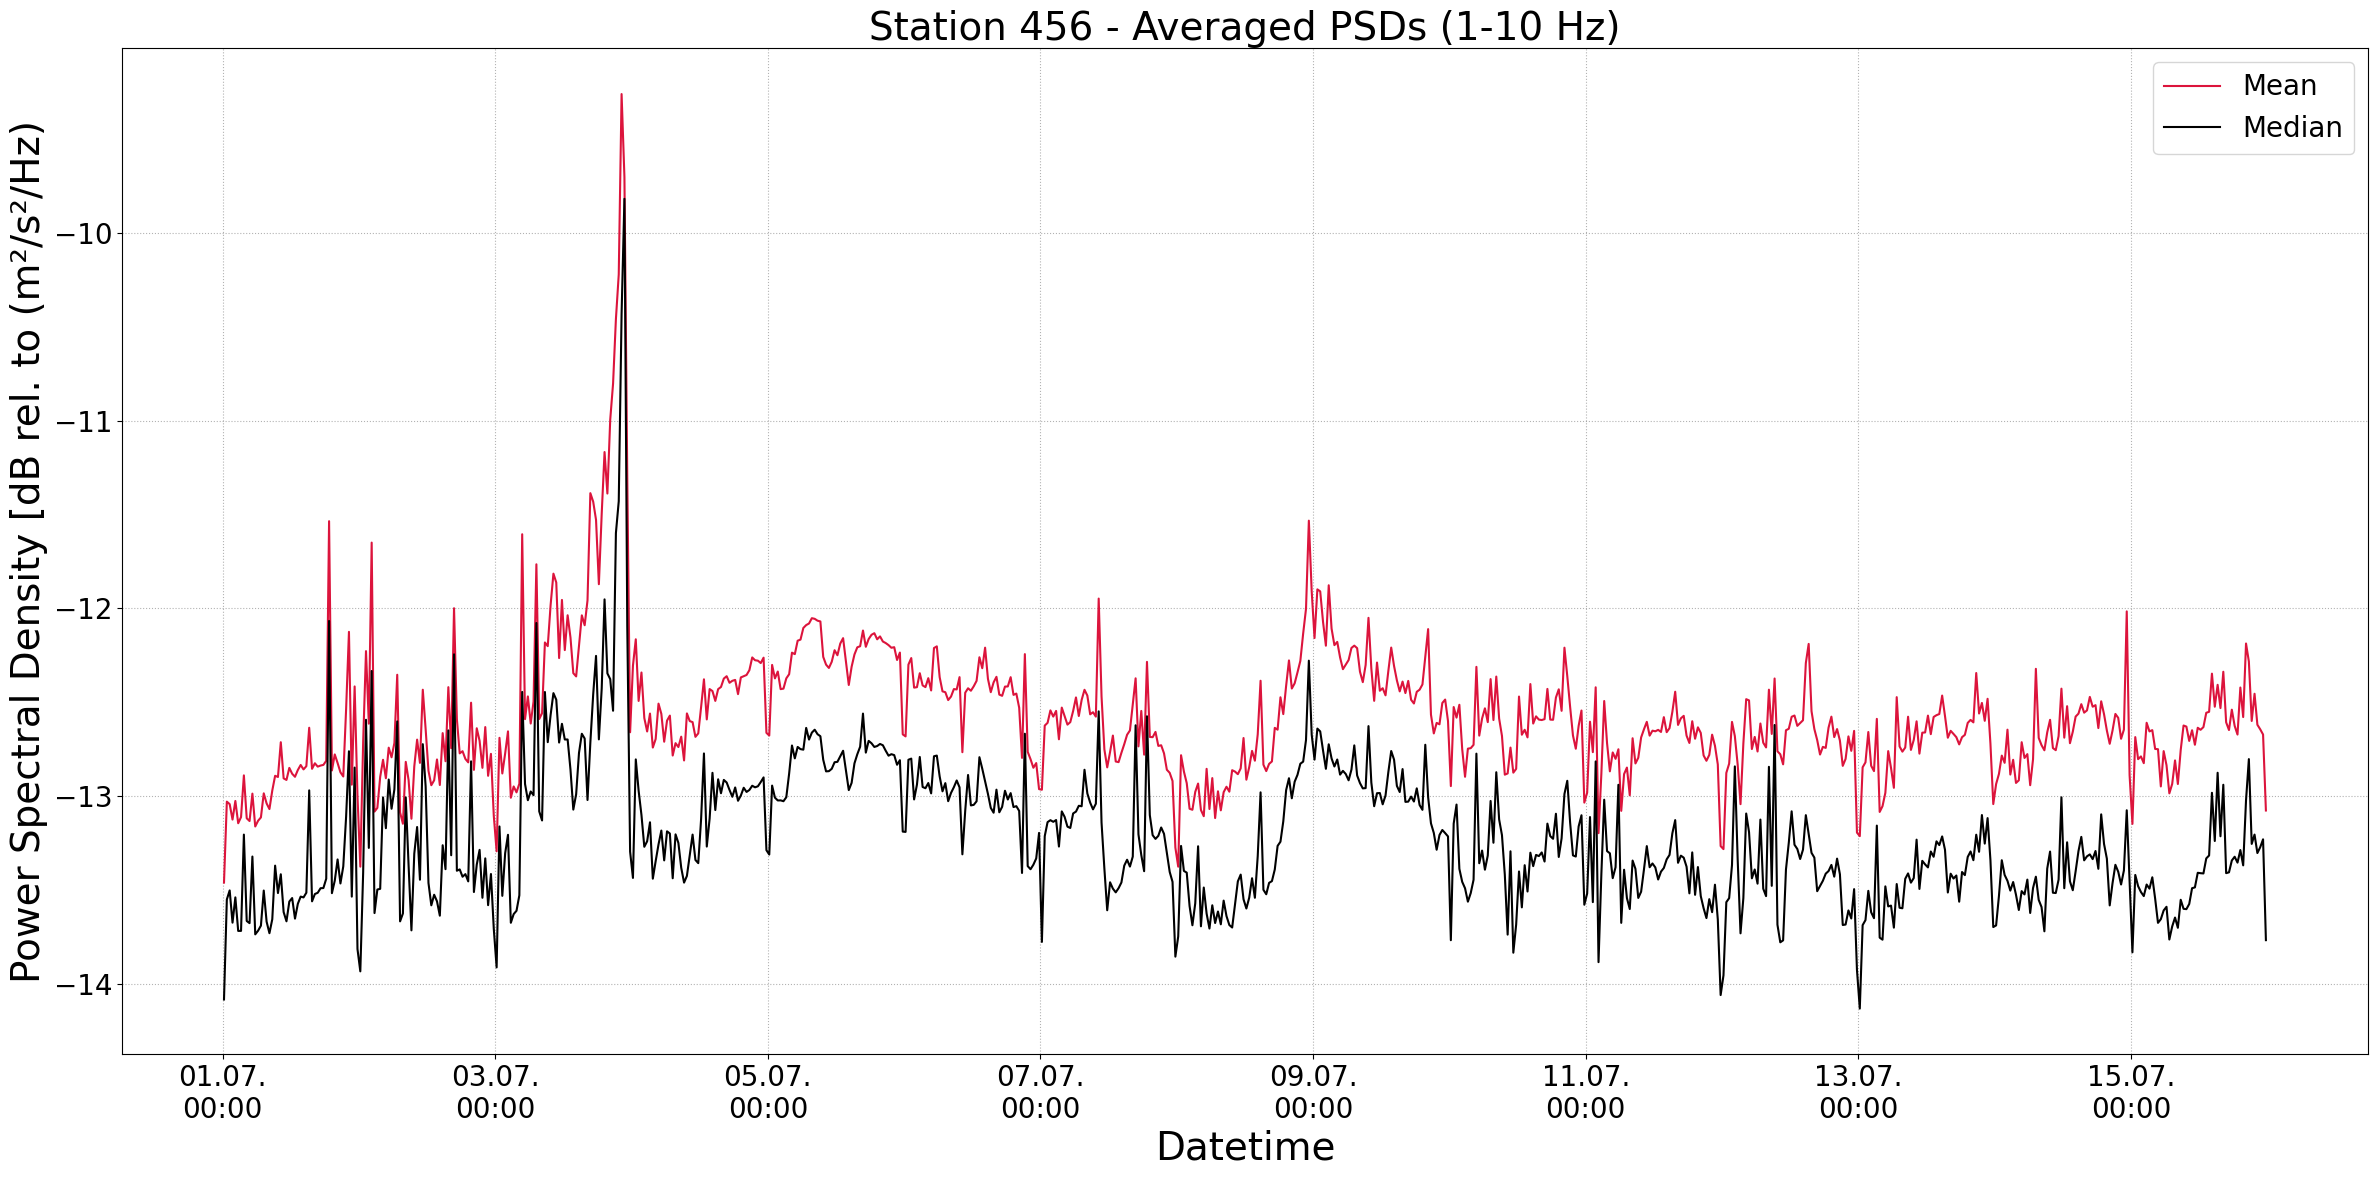

In [3]:
# Plot
# Initialize figure
fig, ax = plt.subplots(figsize=(24, 12))

# Plot the columns directly from the DataFrame
# Slicing the values with np.log10 makes seismic energy shifts much easier to see
ax.plot(df_psd.index, np.log10(df_psd['mean_psd']), label='Mean', color='crimson')
ax.plot(df_psd.index, np.log10(df_psd['median_psd']), label='Median', color='black')

# 3. Format the X-Axis Timestamps
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.\n%H:%M"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))  # Add a date stamp tick every 2 days
ax.grid(True, color='gray', linestyle=':', alpha=0.6)

# 4. Labels and Styling
ax.set_ylabel("Power Spectral Density [dB rel. to (m²/s²/Hz)")
ax.set_xlabel("Datetime")
ax.set_title(f"Station {station} - Averaged PSDs ({fmin}-{fmax} Hz)")
ax.legend(loc='upper right')

# Ensure layout fits tightly without clipping labels
plt.tight_layout()

# Create filename
png_fn = (
    f"{station}_psd_{fmin}_{fmax}Hz"+
    '_'+
    str(df_psd.index.min().strftime("%Y%m%d"))+
    '_'+ 
    str(df_psd.index.max().strftime("%m%d"))+
    '.png'
)

# Save and show plot
figures_dir = base_dir / '03_figures/ap23'
figures_dir.mkdir(parents=True, exist_ok=True)

# replace extension for png figure
png_fn = csv_fn.replace('.csv', '.png')

plt.savefig(figures_dir / png_fn, dpi=300)

plt.show()